# Meteorological Indicators, Exposure, and EF Rating in U.S. Tornadoes, 2010-2025

## 1. Study Overview

This notebook extends an earlier tornado severity classifier to a linked 2010-2025 compilation
of tornado records, nearby radar indicators, archived NWS warnings, and land-cover summaries.
It answers two questions on the same data:

- Modeling question (assignment, Section 5): how do learning rate, SGD, L2 regularization, and
  dropout affect the training, generalization, and overfitting of a deep neural network?
- Primary question (research, Section 6): how do meteorological indicators, tornado
  characteristics, and exposure relate to final EF rating?

EF is a damage-based rating assigned after a survey, not a wind measurement. Final-track
features come from the same survey, so their predictive strength is partly circular.

## 2. Setup

Python 3.12+ with the packages in the first code cell; uncomment the `%pip` line to install
them in a fresh kernel. Paths are relative to the kernel's working folder, and `data/` and
`assets/` are created automatically. Seeds, the split, preprocessing, architecture, and
training settings are fixed in code and shared by every experiment.

In [1]:
# %pip install geopandas kagglehub matplotlib numpy pandas pyarrow scikit-learn tensorflow

import json
import os
import random
import textwrap
from dataclasses import dataclass, replace
from pathlib import Path
from typing import TYPE_CHECKING, Literal

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import geopandas as gpd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# tf.keras loads lazily; the public Keras package provides the same types for static checks.
if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

# Python, NumPy, and TensorFlow seeds; reset again before every model.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

BASE_DIR = Path.cwd()
SOURCE_DIR = BASE_DIR / "data/source/v8"
RESULTS_DIR = BASE_DIR / "data/results"
FIGURE_DIR = BASE_DIR / "assets/figures"
TABLE_DIR = BASE_DIR / "assets/tables"
for directory in (SOURCE_DIR, RESULTS_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [f"EF{i}" for i in range(6)]
N_CLASSES = len(CLASS_NAMES)
# Forward-in-time split: train on earlier tornadoes, validate and test on later ones.
YEARS = {"train": (2010, 2019), "validation": (2020, 2022), "test": (2023, 2025)}
SPLIT_ORDER = list(YEARS)
# Shared training budget for every experiment.
EPOCHS, BATCH_SIZE = 50, 64

EF_COLORS = dict(
    zip(
        [*CLASS_NAMES, "Unknown"],
        ["#F2C94C", "#F29E38", "#ED6A32", "#D93632", "#AD203E", "#650026", "#999999"],
        strict=True,
    )
)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    }
)

I0000 00:00:1789612702.873959 1218945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1789612703.459889 1218945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
def saved(path: Path) -> None:
    print(f"Saved {path.relative_to(BASE_DIR).as_posix()}")


def show_figure(fig: plt.Figure, name: str, caption: str) -> None:
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    saved(path)


def save_table(
    frame: pd.DataFrame,
    name: str,
    title: str,
    *,
    caption: str,
    formats: dict[str, str] | None = None,
    note: str | None = None,
    emphasize: tuple[str, Literal["max", "min"]] | None = None,
    sort: bool = False,
    width: float = 9,
) -> None:
    # Save the numeric CSV plus a styled image; emphasize bolds the best cell of one column.
    best_row, best_column = None, None
    if emphasize is not None:
        best_column, direction = emphasize
        if sort:
            frame = frame.sort_values(best_column, ascending=direction == "min", ignore_index=True)
        ranked = frame[best_column]
        best_row = int(ranked.idxmax() if direction == "max" else ranked.idxmin())
    frame.to_csv(RESULTS_DIR / f"{name}.csv", index=False)
    shown = frame.copy()
    for column, pattern in (formats or {}).items():
        shown[column] = shown[column].map(
            lambda value, pattern=pattern: "-" if pd.isna(value) else format(value, pattern)
        )
    shown = shown.fillna("-").astype(str)
    note_lines = textwrap.wrap(note, width=110) if note else []
    height = 0.34 * (len(frame) + 1.5) + 0.65 + 0.18 * len(note_lines)
    fig, ax = plt.subplots(figsize=(width, height))
    ax.axis("off")
    fig.text(0.03, 1 - 0.22 / height, title, fontsize=12, weight="bold", va="top")
    headers = [textwrap.fill(str(c), width=22) for c in frame.columns]
    column_widths = np.array(
        [
            max(max(map(len, header.splitlines())), shown[column].str.len().max()) + 3
            for column, header in zip(frame.columns, headers, strict=True)
        ],
        dtype=float,
    )
    table = ax.table(
        cellText=shown.values.tolist(),
        colLabels=headers,
        colWidths=column_widths / column_widths.sum(),
        cellLoc="right",
        colLoc="left",
        bbox=Bbox.from_bounds(0, 0, 1, 1),
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#D6DEE5")
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor("#E7EEF4")
            cell.set_text_props(weight="bold", color="#172B3A")
            cell.set_height(cell.get_height() * 1.5)
        else:
            cell.set_facecolor("#F6F8FA" if row % 2 == 0 else "white")
        if col == 0:
            cell.set_text_props(ha="left")
        if best_row is not None and row == best_row + 1 and frame.columns[col] == best_column:
            cell.set_facecolor("#DCEFD9")
            cell.set_text_props(weight="bold")
    if note_lines:
        fig.text(0.03, 0.03, "\n".join(note_lines), fontsize=9, color="#46535F")
    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=1 - 0.55 / height,
        bottom=(0.16 + 0.22 * len(note_lines)) / height,
    )
    path = TABLE_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    saved(path)
    saved(RESULTS_DIR / f"{name}.csv")

## 3. Data

[US Tornado Data, 2010-2025 (v2.2.1, Kaggle version 8)](https://www.kaggle.com/datasets/jakevanslyke/us-tornado-data-2010-2025/versions/8)
is an independent compilation of government-source records. Its retrospective modeling table
has one row per tornado, 20,164 in all, with the final EF rating as target and 32 allowed
predictors from the release's feature dictionary in six groups: location and timing, onset
radar, warnings, final track, full-window radar (through onset +60 minutes), and land cover.
Targets, identifiers, quality fields, injuries, and fatalities are never predictors.

Missing radar maxima can mean no qualifying detection, and missing warning lead time can mean
no active warning, so missingness is encoded rather than dropped.

### Load

In [3]:
DATASET = "jakevanslyke/us-tornado-data-2010-2025/versions/8"
for relative in (
    "ml/events_retrospective.parquet",
    "ml/feature_dictionary.json",
    "analysis/county_boundaries.parquet",
):
    if not (SOURCE_DIR / relative).is_file():
        kagglehub.dataset_download(DATASET, path=relative, output_dir=str(SOURCE_DIR))

spec = json.loads((SOURCE_DIR / "ml/feature_dictionary.json").read_text())
ID, TARGET = spec["id"], spec["target"]
PREDICTORS = spec["retrospective_predictor_columns"]
records = pd.read_parquet(SOURCE_DIR / "ml/events_retrospective.parquet").set_index(ID)
assert records.index.is_unique
known = records[TARGET].notna()
display(
    Markdown(
        f"**{len(records):,} tornado records:** {known.sum():,} with a known EF rating and "
        f"{(~known).sum():,} unknown. {len(PREDICTORS)} allowed predictors."
    )
)

**20,164 tornado records:** 18,639 with a known EF rating and 1,525 unknown. 32 allowed predictors.

### Class balance

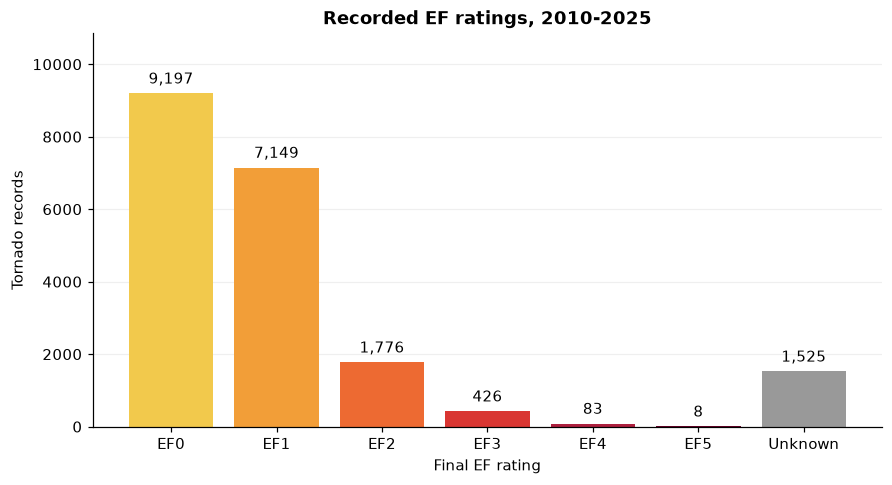

**Figure 1.** Distribution of recorded EF ratings, 2010-2025. Unknown ratings are excluded from modeling; EF4 and EF5 together hold under 100 events.

Saved assets/figures/fig_01_class_distribution.png


In [4]:
rating_labels = records[TARGET].map({i: f"EF{i}" for i in range(6)}).fillna("Unknown")
class_counts = rating_labels.value_counts().reindex(EF_COLORS, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4.3), layout="constrained")
bars = ax.bar(class_counts.index, class_counts, color=[EF_COLORS[c] for c in class_counts.index])
ax.bar_label(bars, labels=[f"{n:,}" for n in class_counts], padding=4, fontsize=10)
ax.set(title="Recorded EF ratings, 2010-2025", ylabel="Tornado records", xlabel="Final EF rating")
ax.set_ylim(0, class_counts.max() * 1.18)
ax.grid(axis="y", alpha=0.2)
show_figure(
    fig,
    "fig_01_class_distribution",
    "**Figure 1.** Distribution of recorded EF ratings, 2010-2025. Unknown ratings are excluded "
    "from modeling; EF4 and EF5 together hold under 100 events.",
)

### Geographic coverage

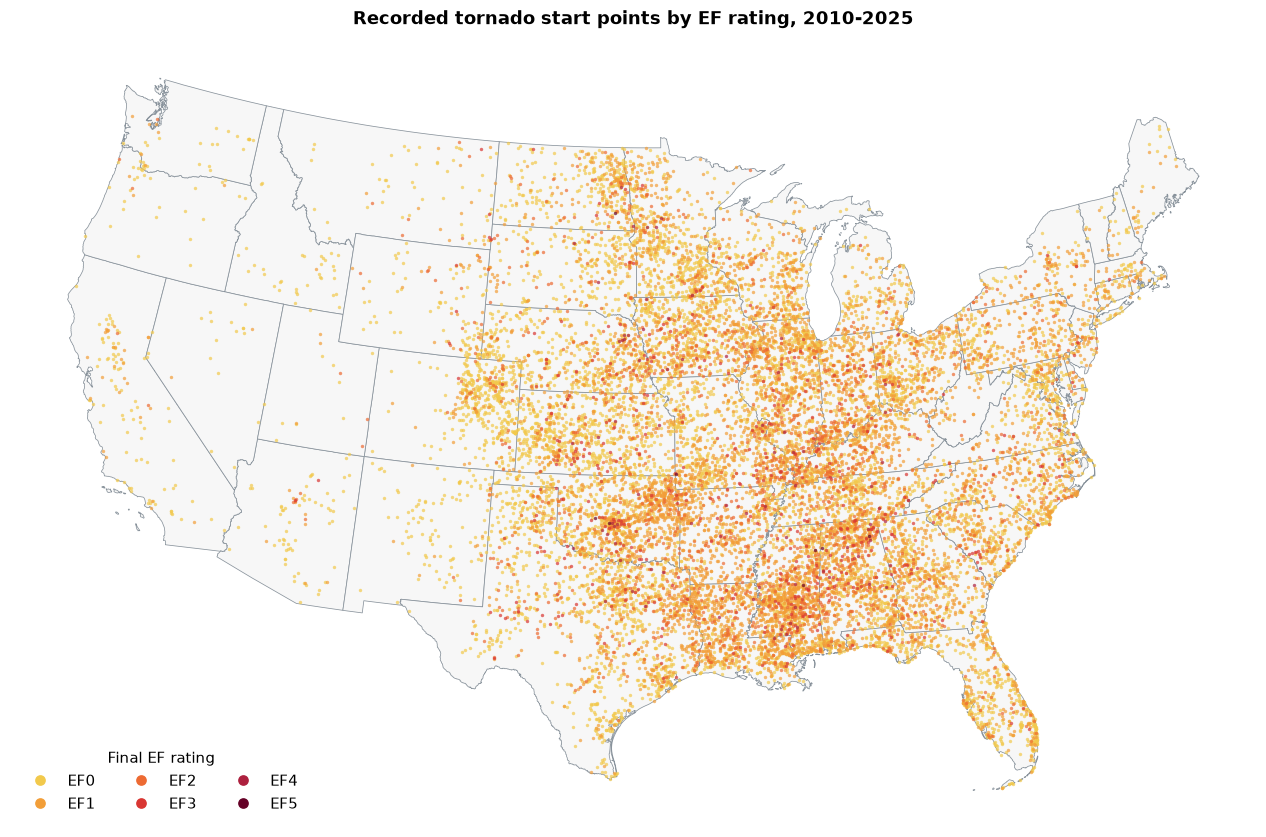

**Figure 2.** Contiguous-U.S. start points of rated tornadoes colored by EF rating. Stronger ratings are drawn last, so overlap can hide weaker points.

Saved assets/figures/fig_02_geographic_distribution.png


In [5]:
# Contiguous U.S. only for the map; the modeling cohort keeps every region.
states = gpd.read_parquet(SOURCE_DIR / "analysis/county_boundaries.parquet").dissolve("state_fips")
states = states.loc[~states.index.isin(["02", "15", "60", "66", "69", "72", "78"])].to_crs(
    "EPSG:5070"
)
rated = records.loc[
    known & records.start_longitude.between(-125, -66) & records.start_latitude.between(24, 50)
]
points = gpd.GeoDataFrame(
    rated[[TARGET]],
    geometry=gpd.points_from_xy(rated.start_longitude, rated.start_latitude),
    crs="EPSG:4326",
).to_crs(states.crs)

fig, ax = plt.subplots(figsize=(12, 7.5), layout="constrained")
states.plot(ax=ax, color="#F7F7F7", edgecolor="#89939C", linewidth=0.5)
for rating, label in enumerate(CLASS_NAMES):
    selected = points.loc[points[TARGET].eq(rating)]
    ax.scatter(
        selected.geometry.x,
        selected.geometry.y,
        s=5,
        alpha=0.7,
        color=EF_COLORS[label],
        linewidths=0,
        zorder=3 + rating,
    )
ax.set_axis_off()
ax.set_title("Recorded tornado start points by EF rating, 2010-2025", pad=12)
ax.legend(
    handles=[
        Line2D([], [], marker="o", linestyle="", markersize=6, color=EF_COLORS[c], label=c)
        for c in CLASS_NAMES
    ],
    loc="lower left",
    frameon=False,
    ncol=3,
    title="Final EF rating",
)
show_figure(
    fig,
    "fig_02_geographic_distribution",
    "**Figure 2.** Contiguous-U.S. start points of rated tornadoes colored by EF rating. Stronger "
    "ratings are drawn last, so overlap can hide weaker points.",
)

## 4. Preparation

Keep EF0-EF5 as six classes and split by year, so every model is trained on earlier tornadoes
and evaluated on later ones: 2010-2019 for training, 2020-2022 for validation, and 2023-2025
for testing. The test years are untouched until the end of Section 5. Unrated tornadoes are
excluded, never treated as EF0.

Month and UTC hour become sine/cosine pairs, skewed counts and track dimensions get a log1p
transform, missing values take the training median plus a missingness indicator, and every
input is standardized. Imputation, scaling, and the log-column choice are fit on the training
years only.

### Split

In [ ]:
eligible = records.loc[known]
cohorts = {split: eligible.loc[eligible.year.between(*span)] for split, span in YEARS.items()}
assert sum(map(len, cohorts.values())) == len(eligible)
y = {split: frame[TARGET].to_numpy(dtype="int64") for split, frame in cohorts.items()}

support_table = pd.DataFrame(
    {
        "EF": CLASS_NAMES,
        **{split.title(): np.bincount(y[split], minlength=N_CLASSES) for split in SPLIT_ORDER},
    }
)
split_note = "; ".join(
    f"{split} {span[0]}-{span[1]}: {len(cohorts[split]):,} events "
    f"({100 * len(cohorts[split]) / len(eligible):.0f}%)"
    for split, span in YEARS.items()
)
save_table(
    support_table,
    "table_01_class_support",
    "EF-class support by split",
    caption="**Table 1.** Forward-in-time split. The validation years contain no EF5 event and "
    "the test years contain one, so EF5 metrics are never dependable.",
    formats={split.title(): ",d" for split in SPLIT_ORDER},
    width=7,
    note=split_note.capitalize() + ".",
)

### Features

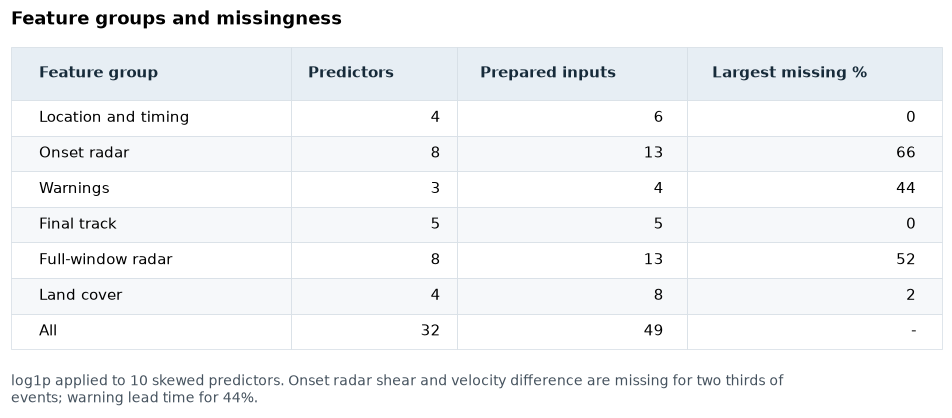

**Table 2.** Predictor and prepared-input counts per feature group, and the largest missing share within each group across all records. Prepared inputs add cyclic time pairs and missingness indicators.

Saved assets/tables/table_02_feature_groups.png
Saved data/results/table_02_feature_groups.csv


In [7]:
feature_groups = {
    "Location and timing": ["start_longitude", "start_latitude", "month", "hour_utc"],
    "Onset radar": [c for c in PREDICTORS if c.startswith("radar_")],
    "Warnings": [c for c in PREDICTORS if c.startswith("warning_")],
    "Final track": [
        "post_end_longitude",
        "post_end_latitude",
        "post_path_length_miles",
        "post_path_width_yards",
        "post_duration_minutes",
    ],
    "Full-window radar": [c for c in PREDICTORS if c.startswith("post_radar_")],
    "Land cover": [
        c for c in PREDICTORS if c.startswith("post_land_") or c == "post_impervious_mean_percent"
    ],
}
assert sorted(c for cols in feature_groups.values() for c in cols) == sorted(PREDICTORS)


def encode_predictors(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    # Fixed transforms only; nothing here is estimated from data.
    encoded = frame[columns].copy()
    # The release stores hour_utc as a datetime; the integer hour comes from onset_utc.
    encoded["hour_utc"] = frame["onset_utc"].dt.hour.astype(float)
    for column, period, offset in [("month", 12, 1), ("hour_utc", 24, 0)]:
        angle = 2 * np.pi * (encoded.pop(column).astype(float) - offset) / period
        encoded[f"{column}_sin"] = np.sin(angle)
        encoded[f"{column}_cos"] = np.cos(angle)
    for column in set(LOG_COLUMNS) & set(columns):
        encoded[column] = np.log1p(encoded[column])
    return encoded.astype(float)


def prepare_inputs(split_frames: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    # Fit imputation and scaling on training rows, then transform every split.
    preprocessor = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    ).fit(split_frames["train"])
    names = preprocessor.get_feature_names_out().tolist()
    return {
        split: pd.DataFrame(
            preprocessor.transform(frame).astype("float32"), index=frame.index, columns=names
        )
        for split, frame in split_frames.items()
    }


def scope_columns(raw_predictors: list[str]) -> list[str]:
    # Prepared columns for a raw predictor list: cyclic pairs and missingness indicators included.
    keep: set[str] = set()
    for column in raw_predictors:
        keep |= {f"{column}_sin", f"{column}_cos"} if column in ("month", "hour_utc") else {column}
        keep.add(f"missingindicator_{column}")
    return [c for c in X["train"].columns if c in keep]


# Nonnegative counts, track dimensions, and impervious percent with training skew above one.
train_skew = cohorts["train"][PREDICTORS].skew(numeric_only=True)
log_candidates = [
    c
    for c in PREDICTORS
    if c.endswith("_count")
    or c.startswith("post_path_")
    or c in ("post_duration_minutes", "post_impervious_mean_percent")
]
LOG_COLUMNS = [c for c in log_candidates if train_skew[c] > 1]
X = prepare_inputs(
    {split: encode_predictors(frame, PREDICTORS) for split, frame in cohorts.items()}
)
for split in SPLIT_ORDER:
    assert X[split].index.equals(cohorts[split].index)
    assert np.isfinite(X[split].to_numpy()).all()

missing_percent = 100 * records[PREDICTORS].isna().mean()
group_table = pd.DataFrame(
    [
        {
            "Feature group": group,
            "Predictors": len(columns),
            "Prepared inputs": len(scope_columns(columns)),
            "Largest missing %": missing_percent[columns].max(),
        }
        for group, columns in feature_groups.items()
    ]
    + [
        {
            "Feature group": "All",
            "Predictors": len(PREDICTORS),
            "Prepared inputs": X["train"].shape[1],
        }
    ]
)
save_table(
    group_table,
    "table_02_feature_groups",
    "Feature groups and missingness",
    caption="**Table 2.** Predictor and prepared-input counts per feature group, and the largest "
    "missing share within each group across all records. Prepared inputs add cyclic time pairs "
    "and missingness indicators.",
    formats={"Predictors": "d", "Prepared inputs": "d", "Largest missing %": ".0f"},
    note=f"log1p applied to {len(LOG_COLUMNS)} skewed predictors. Onset radar shear and velocity "
    "difference are missing for two thirds of events; warning lead time for 44%.",
)

## 5. Assignment Experiments

One network, one split, one seed. The baseline has three ReLU hidden layers of 128, 64, and 32
units and a six-class softmax output, trained with Adam at 0.001, sparse categorical
cross-entropy with balanced class weights (inverse training frequency, normalized to a mean of
one, so an EF5 row counts about 280 times an EF0 row), batch size 64, and 50 epochs. Every later run
changes exactly one setting: the optimizer and learning rate (SGD at 0.1, 0.01, and 0.001), L2
on the hidden layers (0.001), or dropout after the first two hidden layers (0.2 and 0.5).

Learning curves show the Keras training and validation loss and accuracy by epoch. Validation
uses the same class weights as training so the two loss curves are comparable; the training
loss also includes any L2 penalty, and dropout is active only during training. Because EF0 and
EF1 are most of the events, runs are compared by final-epoch validation macro F1 over the
classes present in the split, with validation loss as the tie-breaker. The best run is the
final model and is scored once on the test years.

In [8]:
@dataclass(frozen=True)
class RunConfig:
    name: str
    optimizer: Literal["Adam", "SGD"] = "Adam"
    learning_rate: float = 0.001
    l2: float = 0.0
    dropout: float = 0.0
    # Section 6 extensions; the defaults give the assignment's plain softmax network.
    head: Literal["softmax", "ordinal", "ladder"] = "softmax"
    weighting: Literal["balanced", "sqrt", "none"] = "balanced"
    sampling: Literal["full", "partial"] = "full"
    members: int = 1


@dataclass
class RunResult:
    config: RunConfig
    models: list[keras.Model]
    epochs: pd.DataFrame
    metrics: dict[str, float]
    completed: bool


HIDDEN_UNITS = (128, 64, 32)
METRIC_NAMES = ("accuracy", "cross_entropy", "macro_f1", "ef_mae", "within_one")


def build_model(n_features: int, config: RunConfig, *, seed: int) -> keras.Model:
    model = keras.Sequential([keras.layers.Input(shape=(n_features,))])
    for index, units in enumerate(HIDDEN_UNITS):
        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_initializer=keras.initializers.GlorotUniform(seed=seed + index),
                kernel_regularizer=keras.regularizers.l2(config.l2) if config.l2 else None,
            )
        )
        if config.dropout and index < 2:
            model.add(keras.layers.Dropout(config.dropout, seed=seed + 100 + index))
    if config.head == "softmax":
        model.add(
            keras.layers.Dense(
                N_CLASSES,
                activation="softmax",
                kernel_initializer=keras.initializers.GlorotUniform(seed=seed + 3),
            )
        )
        loss, accuracy = keras.losses.SparseCategoricalCrossentropy(), "accuracy"
    else:
        loss, accuracy = add_threshold_head(model, config, seed=seed)  # defined in Section 6
    optimizer = (
        keras.optimizers.Adam(config.learning_rate)
        if config.optimizer == "Adam"
        else keras.optimizers.SGD(config.learning_rate)
    )
    model.compile(optimizer=optimizer, loss=loss, metrics=[accuracy])
    return model


def class_probabilities(model: keras.Model, features: np.ndarray, head: str) -> np.ndarray:
    output = model(features, training=False)
    if head != "softmax":
        output = ThresholdProbabilities()(output)  # defined in Section 6
    return np.asarray(output, dtype="float32")


def predict(result: RunResult, features: np.ndarray) -> np.ndarray:
    # Mean class probabilities across members (one member for the assignment runs).
    return np.mean(
        [class_probabilities(m, features, result.config.head) for m in result.models], axis=0
    )


def prediction_metrics(labels: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:
    if not np.isfinite(probabilities).all():
        return dict.fromkeys(METRIC_NAMES, float("nan"))
    predictions = probabilities.argmax(axis=1)
    scored = probabilities.astype("float64")
    scored /= scored.sum(axis=1, keepdims=True)
    error = np.abs(predictions - labels)
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "cross_entropy": float(log_loss(labels, scored, labels=range(N_CLASSES))),
        # Macro F1 over the classes present in the split; absent classes are not counted as zero.
        "macro_f1": float(
            f1_score(
                labels, predictions, labels=np.unique(labels), average="macro", zero_division=0
            )
        ),
        "ef_mae": float(error.mean()),
        "within_one": float((error <= 1).mean()),
    }


def training_weights(labels: np.ndarray, weighting: str) -> np.ndarray:
    # Per-class weights normalized to a mean sample weight of one.
    exponent = {"none": 0.0, "sqrt": 0.5, "balanced": 1.0}[weighting]
    weights = np.bincount(labels, minlength=N_CLASSES).astype(float) ** -exponent
    return (weights / weights[labels].mean()).astype("float32")


def train_run(
    config: RunConfig, features: dict[str, np.ndarray], labels: dict[str, np.ndarray]
) -> RunResult:
    models, member_frames = [], []
    for member in range(config.members):
        seed = SEED + 1000 * member
        keras.utils.set_random_seed(seed)
        if config.sampling == "full":
            rows = np.arange(len(labels["train"]))
        else:
            rows = balanced_subset(labels["train"], seed=seed)  # defined in Section 6
        sampled_labels = labels["train"][rows]
        class_weight = training_weights(sampled_labels, config.weighting)
        model = build_model(features["train"].shape[1], config, seed=seed)
        dataset = (
            tf.data.Dataset.from_tensor_slices(
                (features["train"][rows], sampled_labels, class_weight[sampled_labels])
            )
            .shuffle(len(rows), seed=seed, reshuffle_each_iteration=True)
            .batch(BATCH_SIZE)
        )
        # Validation carries the same class weights so its loss is comparable with training.
        history = model.fit(
            dataset,
            validation_data=(
                features["validation"],
                labels["validation"],
                class_weight[labels["validation"]],
            ),
            epochs=EPOCHS,
            shuffle=False,
            verbose=0,
            callbacks=[keras.callbacks.TerminateOnNaN()],
        )
        frame = pd.DataFrame(history.history)
        frame.insert(0, "epoch", np.arange(1, len(frame) + 1))
        models.append(model)
        member_frames.append(frame)
    epochs = pd.concat(member_frames).groupby("epoch", as_index=False).mean()
    completed = len(epochs) == EPOCHS and bool(np.isfinite(epochs.to_numpy()).all())
    result = RunResult(config, models, epochs, {}, completed)
    result.metrics = {
        "loss": float(epochs.loss.iloc[-1]),
        "val_loss": float(epochs.val_loss.iloc[-1]),
    }
    for split in ("train", "validation"):
        scores = prediction_metrics(labels[split], predict(result, features[split]))
        result.metrics.update({f"{split}_{k}": v for k, v in scores.items()})
    print(
        f"{config.name}: {len(epochs)}/{EPOCHS} epochs, validation accuracy "
        f"{result.metrics['validation_accuracy']:.3f}, macro F1 "
        f"{result.metrics['validation_macro_f1']:.3f}{'' if completed else ' (unstable)'}"
    )
    return result


results: dict[str, RunResult] = {}
run_columns: dict[str, list[str]] = {}


def run(config: RunConfig, *, columns: list[str] | None = None) -> RunResult:
    columns = X["train"].columns.tolist() if columns is None else columns
    features = {split: X[split][columns].to_numpy(dtype="float32") for split in SPLIT_ORDER}
    results[config.name] = train_run(config, features, y)
    run_columns[config.name] = columns
    return results[config.name]


def final_metric(result: RunResult, metric: str) -> float:
    return result.metrics[metric]


def select_best(candidates: dict[str, RunResult]) -> RunResult:
    stable = [r for r in candidates.values() if r.completed]
    return min(
        stable,
        key=lambda r: (-final_metric(r, "validation_macro_f1"), final_metric(r, "val_loss")),
    )


def plot_baseline_curves(name: str, *, title: str) -> plt.Figure:
    epochs = results[name].epochs
    best_epoch = int(epochs.epoch[epochs.val_loss.idxmin()])
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), layout="constrained")
    for ax, (metric, ylabel) in zip(
        axes, [("loss", "Loss"), ("accuracy", "Accuracy")], strict=True
    ):
        ax.plot(epochs.epoch, epochs[metric], color="#0072B2", label="Training")
        ax.plot(epochs.epoch, epochs[f"val_{metric}"], "--", color="#D55E00", label="Validation")
        ax.axvline(
            best_epoch,
            color="#8A939B",
            linestyle=":",
            linewidth=1,
            label=f"Min validation loss (epoch {best_epoch})",
        )
        ax.set(title=ylabel, xlabel="Epoch", ylabel=ylabel)
        ax.grid(alpha=0.2)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(title, weight="bold")
    return fig


RUN_COLORS = {
    "Baseline": "#333333",
    "GD-1": "#9ECAE1",
    "GD-2": "#3182BD",
    "GD-3": "#08519C",
    "L2": "#31A354",
    "Dropout-1": "#FDAE6B",
    "Dropout-2": "#E6550D",
}


def plot_run_groups(groups: dict[str, list[str]], *, title: str) -> plt.Figure:
    # Columns: one run group each; rows: loss and accuracy. Validation solid, training dotted.
    fig, axes = plt.subplots(
        2,
        len(groups),
        figsize=(5.2 * len(groups), 6.5),
        sharex=True,
        sharey="row",
        layout="constrained",
    )
    for column, (group, names) in enumerate(groups.items()):
        for row, (metric, ylabel) in enumerate([("loss", "Loss"), ("accuracy", "Accuracy")]):
            ax = axes[row, column]
            for name in names:
                epochs = results[name].epochs
                color = RUN_COLORS[name]
                ax.plot(
                    epochs.epoch, epochs[f"val_{metric}"], color=color, linewidth=1.6, label=name
                )
                ax.plot(epochs.epoch, epochs[metric], color=color, linewidth=1, linestyle=":")
            ax.grid(alpha=0.2)
            if row == 0:
                ax.set_title(group, fontsize=11)
                ax.legend(frameon=False, fontsize=8, ncol=2)
            else:
                ax.set_xlabel("Epoch")
            if column == 0:
                ax.set_ylabel(ylabel)
    fig.suptitle(title + " (validation solid, training dotted)", weight="bold")
    return fig


def evaluate_test(result: RunResult) -> dict:
    # Score one model once on the test years.
    probabilities = predict(result, X["test"][run_columns[result.config.name]].to_numpy("float32"))
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1_values, support = precision_recall_fscore_support(
        y["test"], predictions, labels=range(N_CLASSES), zero_division=0
    )
    return {
        **prediction_metrics(y["test"], probabilities),
        "majority": float((y["test"] == np.bincount(y["train"]).argmax()).mean()),
        "matrix": confusion_matrix(y["test"], predictions, labels=range(N_CLASSES)),
        "precision": precision,
        "recall": recall,
        "f1": f1_values,
        "support": support,
    }


def show_test_figure(result: RunResult, scores: dict, *, number: int, slug: str) -> None:
    label = result.config.name
    fig, (left, right) = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
    matrix = scores["matrix"]
    shares = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    left.imshow(shares, cmap="Blues", vmin=0, vmax=1)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            left.text(
                j,
                i,
                f"{shares[i, j]:.2f}\n({matrix[i, j]:,})",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if shares[i, j] > 0.5 else "#172B3A",
            )
    left.set(
        xticks=range(N_CLASSES),
        yticks=range(N_CLASSES),
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        xlabel="Predicted EF",
        ylabel="True EF",
        title="Confusion matrix, row-normalized (count)",
    )
    left.spines[:].set_visible(False)
    positions = np.arange(N_CLASSES)
    for offset, key, name, color in [
        (-0.27, "precision", "Precision", "#0072B2"),
        (0.0, "recall", "Recall", "#E69F00"),
        (0.27, "f1", "F1", "#009E73"),
    ]:
        bars = right.bar(positions + offset, scores[key], width=0.27, color=color, label=name)
        right.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)
    right.set(
        xticks=positions,
        xticklabels=[f"{c}\nn={n:,}" for c, n in zip(CLASS_NAMES, scores["support"], strict=True)],
        ylim=(0, 1.05),
        ylabel="Score",
        title="Per-class precision, recall, and F1",
    )
    right.legend(frameon=False, ncol=3, loc="upper right")
    right.grid(axis="y", alpha=0.2)
    fig.suptitle(
        f"Test years: {label} model, accuracy {scores['accuracy']:.3f} vs. majority "
        f"{scores['majority']:.3f}, macro F1 {scores['macro_f1']:.3f}",
        weight="bold",
    )
    show_figure(
        fig,
        f"fig_{number:02d}_test_{slug}",
        f"**Figure {number}.** Test-year confusion matrix and per-class metrics for the {label} "
        "model. Cells show the share of each true class (row) with counts in parentheses.",
    )


SUMMARY_ROWS = [
    ("Accuracy", "accuracy"),
    ("Majority-class accuracy", "majority"),
    ("Cross-entropy (unweighted)", "cross_entropy"),
    ("Macro F1", "macro_f1"),
    ("Mean absolute EF error", "ef_mae"),
    ("Within one EF category", "within_one"),
]

### Baseline

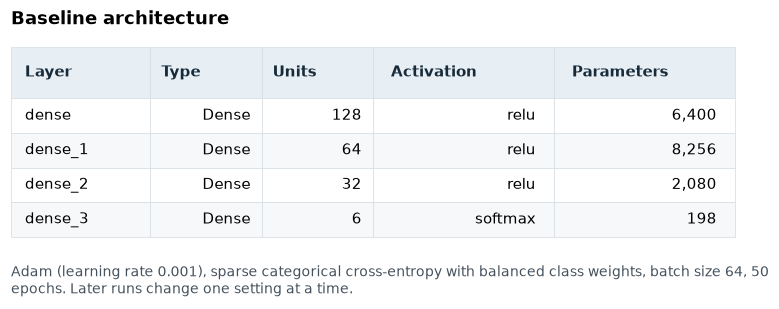

**Table 3.** Baseline network: 49 inputs, three ReLU hidden layers, six-class softmax output, 16,934 trainable parameters.

Saved assets/tables/table_03_baseline_architecture.png
Saved data/results/table_03_baseline_architecture.csv


In [9]:
keras.utils.set_random_seed(SEED)
baseline_config = RunConfig("Baseline")
n_inputs = X["train"].shape[1]
architecture = build_model(n_inputs, baseline_config, seed=SEED)
layer_table = pd.DataFrame(
    [
        {
            "Layer": layer.name,
            "Type": type(layer).__name__,
            "Units": layer.units,
            "Activation": layer.activation.__name__,
            "Parameters": layer.count_params(),
        }
        for layer in architecture.layers
    ]
)
save_table(
    layer_table,
    "table_03_baseline_architecture",
    "Baseline architecture",
    caption=f"**Table 3.** Baseline network: {n_inputs} inputs, three ReLU hidden layers, "
    f"six-class softmax output, {architecture.count_params():,} trainable parameters.",
    formats={"Units": "d", "Parameters": ",d"},
    note="Adam (learning rate 0.001), sparse categorical cross-entropy with balanced class "
    "weights, batch size 64, 50 epochs. Later runs change one setting at a time.",
    width=7,
)

Baseline: 50/50 epochs, validation accuracy 0.568, macro F1 0.448


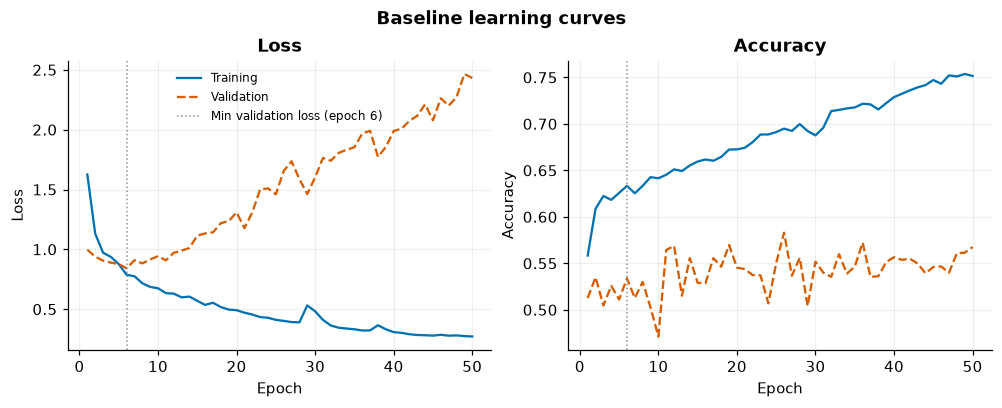

**Figure 3.** Baseline training and validation loss and accuracy by epoch. Both losses use the same class weights; the dotted line marks the epoch of minimum validation loss.

Saved assets/figures/fig_03_baseline_learning_curves.png


In [10]:
baseline = run(baseline_config)
fig = plot_baseline_curves("Baseline", title="Baseline learning curves")
show_figure(
    fig,
    "fig_03_baseline_learning_curves",
    "**Figure 3.** Baseline training and validation loss and accuracy by epoch. Both losses "
    "use the same class weights; the dotted line marks the epoch of minimum validation loss.",
)

**Readout**

- The baseline overfits early. Validation loss bottoms out at 0.84 in epoch 6 and climbs to 2.43
  by epoch 50 while training loss keeps falling to 0.27; training accuracy reaches 0.77 while
  validation stays near 0.55.
- Final validation: accuracy 0.568, macro F1 0.448 over the five classes present in 2020-2022.
- The validation curves are jumpy because balanced weights make the seven EF5 training rows
  count as much as hundreds of EF0 rows, so each epoch's fit to them moves the whole curve.

### Gradient descent and learning rate

Same architecture, data, seeds, and epoch budget as the baseline, with plain SGD replacing
Adam at learning rates 0.1, 0.01, and 0.001. Each epoch is 184 optimizer updates, so a run
sees 9,200 updates in total.

In [11]:
for name, learning_rate in [("GD-1", 0.1), ("GD-2", 0.01), ("GD-3", 0.001)]:
    run(replace(baseline_config, name=name, optimizer="SGD", learning_rate=learning_rate))

GD-1: 50/50 epochs, validation accuracy 0.355, macro F1 0.225


GD-2: 50/50 epochs, validation accuracy 0.564, macro F1 0.465


GD-3: 50/50 epochs, validation accuracy 0.532, macro F1 0.376


### Regularization

Return to the baseline (Adam, 0.001) and add one regularizer at a time: L2 of 0.001 on the
hidden layers, then dropout of 0.2 and 0.5 after the first two hidden layers. L2 penalizes
large weights in the training loss; dropout randomly silences units during training only.
The validation curves see neither, which is why they can sit below the training curves.

In [12]:
run(replace(baseline_config, name="L2", l2=0.001))
for name, rate in [("Dropout-1", 0.2), ("Dropout-2", 0.5)]:
    run(replace(baseline_config, name=name, dropout=rate))

L2: 50/50 epochs, validation accuracy 0.540, macro F1 0.438


Dropout-1: 50/50 epochs, validation accuracy 0.550, macro F1 0.448


Dropout-2: 50/50 epochs, validation accuracy 0.532, macro F1 0.449


### Results and final model

The final model is the run with the highest final-epoch validation macro F1, with validation
loss as the tie-breaker. Every run changed exactly one setting from the baseline, so the winner
also identifies which single change mattered most. Only that model is scored on the test years,
once.

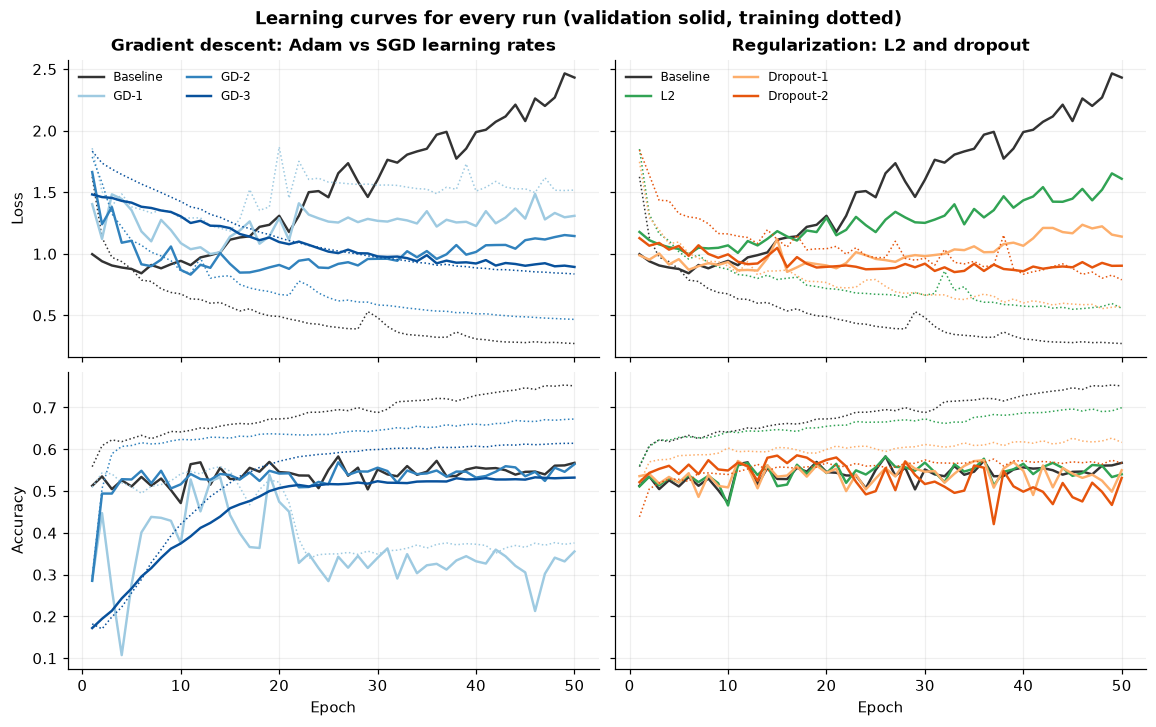

**Figure 4.** Validation (solid) and training (dotted) loss and accuracy by epoch for every run, with the baseline repeated in both groups as the reference. Both losses use the same class weights; training loss also includes any L2 penalty and dropout noise.

Saved assets/figures/fig_04_assignment_learning_curves.png


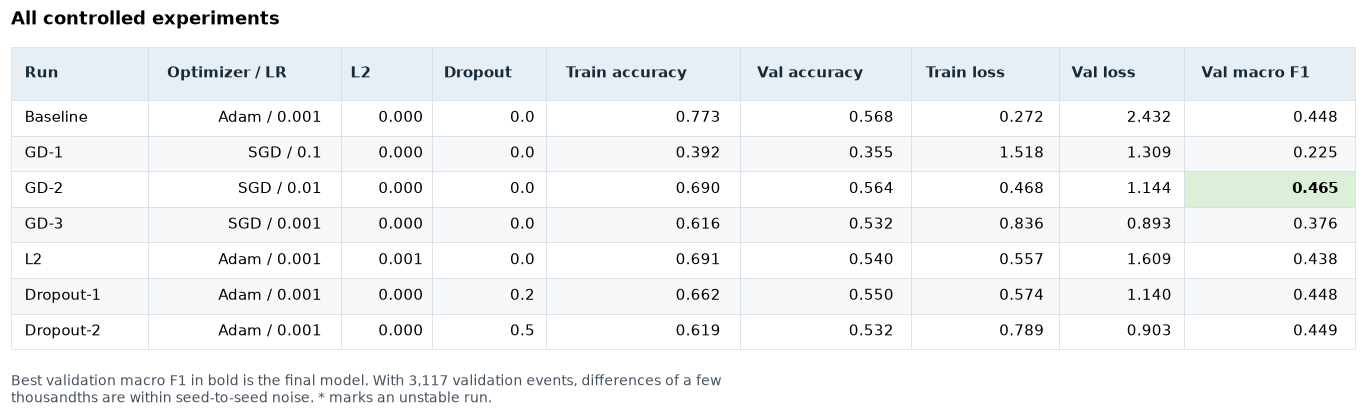

**Table 4.** Final-epoch results for every run. Losses are the class-weighted Keras losses on each split, with any L2 penalty included on the training side; accuracy is unweighted.

Saved assets/tables/table_04_training_experiments.png
Saved data/results/table_04_training_experiments.csv


**Final assignment model: GD-2.**

In [13]:
fig = plot_run_groups(
    {
        "Gradient descent: Adam vs SGD learning rates": ["Baseline", "GD-1", "GD-2", "GD-3"],
        "Regularization: L2 and dropout": ["Baseline", "L2", "Dropout-1", "Dropout-2"],
    },
    title="Learning curves for every run",
)
show_figure(
    fig,
    "fig_04_assignment_learning_curves",
    "**Figure 4.** Validation (solid) and training (dotted) loss and accuracy by epoch for every "
    "run, with the baseline repeated in both groups as the reference. Both losses use the same "
    "class weights; training loss also includes any L2 penalty and dropout noise.",
)

candidates = {
    name: results[name]
    for name in ["Baseline", "GD-1", "GD-2", "GD-3", "L2", "Dropout-1", "Dropout-2"]
}
selected = select_best(candidates)
comparison = pd.DataFrame(
    [
        {
            "Run": name + ("" if result.completed else "*"),
            "Optimizer / LR": f"{result.config.optimizer} / {result.config.learning_rate:g}",
            "L2": result.config.l2,
            "Dropout": result.config.dropout,
            "Train accuracy": final_metric(result, "train_accuracy"),
            "Val accuracy": final_metric(result, "validation_accuracy"),
            "Train loss": final_metric(result, "loss"),
            "Val loss": final_metric(result, "val_loss"),
            "Val macro F1": final_metric(result, "validation_macro_f1"),
        }
        for name, result in candidates.items()
    ]
)
save_table(
    comparison,
    "table_04_training_experiments",
    "All controlled experiments",
    caption="**Table 4.** Final-epoch results for every run. Losses are the class-weighted "
    "Keras losses on each split, with any L2 penalty included on the training side; accuracy "
    "is unweighted.",
    formats={"L2": ".3f", "Dropout": ".1f", **{c: ".3f" for c in comparison.columns[4:]}},
    emphasize=("Val macro F1", "max"),
    width=13,
    note="Best validation macro F1 in bold is the final model. With 3,117 validation events, "
    "differences of a few thousandths are within seed-to-seed noise. * marks an unstable run.",
)
display(Markdown(f"**Final assignment model: {selected.config.name}.**"))

**Readout**

- 0.1 was too large: GD-1 never settled, with accuracy swinging between 0.1 and 0.55 and repeated
  loss spikes, and finished at 0.355 accuracy and 0.225 macro F1. 0.001 was too small: GD-3 is
  still converging at epoch 50 with no train-validation gap (loss 0.84 vs 0.89) and macro F1
  0.376.
- 0.01 learned fastest of the stable runs, reaching 0.5 validation accuracy by epoch 3, and gave
  the best macro F1 in the notebook (0.465). Its validation loss still turns up after epoch 11,
  from 0.83 to 1.14, but far less than Adam's.
- Adam fit the training data much harder (loss 0.27 vs 0.47 for GD-2) and overfit much worse
  (validation loss 2.43 vs 1.14). Each update moves the weights against the batch gradient by
  the learning rate: 0.1 overshot, 0.001 barely moved them, and Adam's adaptive steps found the
  training minimum fastest but generalized worst.
- All three regularizers tamed the baseline's runaway validation loss: at epoch 50 it is 1.61
  with L2, 1.14 with dropout 0.2, and 0.90 with dropout 0.5, against 2.43 unregularized, while
  training accuracy fell from 0.77 to 0.69, 0.66, and 0.62.
- None of them improved validation macro F1 (0.438, 0.448, 0.449 vs 0.448) and accuracy slipped
  two to four points, so on this data regularization bought calibration, not class balance.
- Dropout 0.5 was the most aggressive: training and validation loss meet by epoch 30, and the
  validation curve turns erratic after epoch 20. Training accuracy drops under dropout because
  half the hidden units are silenced while training; validation is scored with all of them.

### Test evaluation

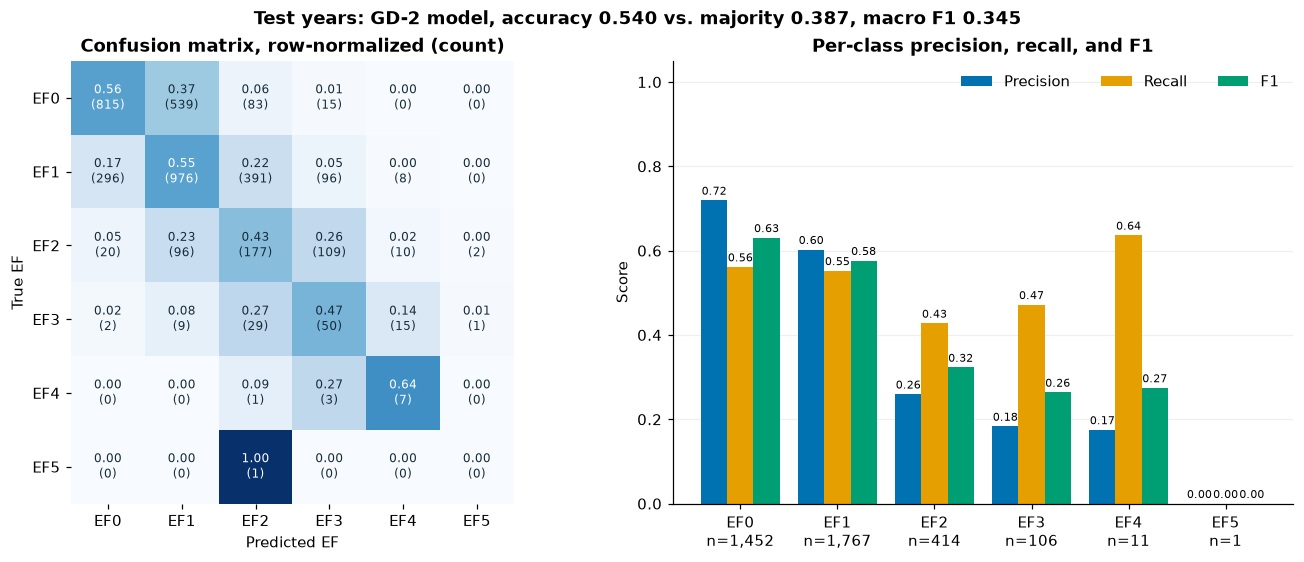

**Figure 5.** Test-year confusion matrix and per-class metrics for the GD-2 model. Cells show the share of each true class (row) with counts in parentheses.

Saved assets/figures/fig_05_test_assignment.png


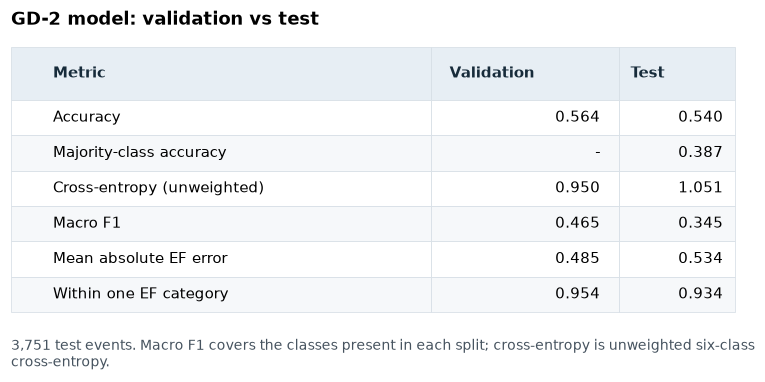

**Table 5.** The final assignment model on the validation years (2020-2022) used for selection and the test years (2023-2025), scored once.

Saved assets/tables/table_05_assignment_test_summary.png
Saved data/results/table_05_assignment_test_summary.csv


In [14]:
assignment_test = evaluate_test(selected)
show_test_figure(selected, assignment_test, number=5, slug="assignment")
summary = pd.DataFrame(
    {
        "Metric": [label for label, _ in SUMMARY_ROWS],
        "Validation": [
            None if key == "majority" else final_metric(selected, f"validation_{key}")
            for _, key in SUMMARY_ROWS
        ],
        "Test": [assignment_test[key] for _, key in SUMMARY_ROWS],
    }
)
save_table(
    summary,
    "table_05_assignment_test_summary",
    f"{selected.config.name} model: validation vs test",
    caption="**Table 5.** The final assignment model on the validation years (2020-2022) used for "
    "selection and the test years (2023-2025), scored once.",
    formats={"Validation": ".3f", "Test": ".3f"},
    width=7,
    note=f"{len(y['test']):,} test events. Macro F1 covers the classes present in each split; "
    "cross-entropy is unweighted six-class cross-entropy.",
)

**Readout**

- GD-2 (SGD at 0.01) is the final model at 0.465 validation macro F1, ahead of dropout 0.5
  (0.449), the baseline and dropout 0.2 (0.448), and L2 (0.438).
- On the 2023-2025 test years it scores 0.540 accuracy against a 0.387 majority baseline and
  keeps 93% of predictions within one EF category. Macro F1 over six classes is 0.345; the single
  EF5 scores zero, so over the five classes with real support it is 0.414, down from 0.465.
- Most of that drop is drift: EF1 became the largest class in the test years (47%) and 37% of
  true EF0 tornadoes are called EF1. Severe classes are found but over-called, with EF3 recall
  0.47 at 0.18 precision and EF4 recall 7 of 11. The one EF5 was predicted as EF2.

## 6. Severity Modeling and the Primary Question

Start from the final assignment model and add one idea at a time, keeping a step only if it
raises validation macro F1 over the best model so far:

1. Ordinal head: one latent severity score with five ordered cutpoints giving P(EF > k). EF is
   ordered, the score doubles as a regression-style severity, and an EF0 called EF3 fails three
   thresholds, so distance is penalized without a separate loss.
2. Threshold ladder: the same five questions, is EF > 0 through is EF > 4, but each answered by
   its own output unit instead of one shared score, so each boundary can depend on different
   features. A running minimum keeps the threshold probabilities monotone before they are
   converted to class probabilities.
3. Balanced-subset ensemble: three members, each trained on every EF2-EF5 row plus an EF2-sized
   sample of EF0 and EF1, with square-root class weights. Builds on the best model so far.
4. Ladder subset ensemble: the same ensemble on the threshold ladder, so the ordering idea is
   tested with and without the ensemble even if the ladder lost on its own.

Optimizer, learning rate, L2, dropout, batch size, epochs, and seeds stay as selected in
Section 5. The best kept model is retrained without each feature group to answer the primary
question and, if it differs from the assignment model, scored once on the test years.
Cumulative ordinal heads follow Cao et al. (2019, https://arxiv.org/abs/1901.07884); subset
ensembling adapts Liu et al. (2009, https://cs.nju.edu.cn/zhouzh/zhouzh.files/publication/tsmcb09.pdf).
Pairwise ranking losses need a different training loop and remain a follow-up.

### Cumulative steps

In [15]:
class OrderedLogits(keras.layers.Layer):
    # Shift one score by five ordered cutpoints: logits for P(EF > k), k = 0..4.
    def build(self, input_shape: tuple[int | None, ...]) -> None:
        self.first = self.add_weight(name="first", shape=(), initializer="zeros")
        self.gaps = self.add_weight(name="gaps", shape=(N_CLASSES - 2,), initializer="zeros")
        super().build(input_shape)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        offsets = tf.concat([tf.zeros((1,)), tf.cumsum(tf.nn.softplus(self.gaps))], axis=0)
        return inputs - (self.first + offsets)[None, :]


class ThresholdProbabilities(keras.layers.Layer):
    # Convert five threshold logits P(EF > k) into six class probabilities. A running minimum
    # keeps the thresholds monotone; it is a no-op for the ordered cutpoints of the ordinal head.
    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        above = tf.math.sigmoid(inputs)
        columns = [above[:, :1]]
        for k in range(1, N_CLASSES - 1):
            columns.append(tf.minimum(columns[-1], above[:, k : k + 1]))
        above = tf.concat(columns, axis=1)
        return tf.concat([1 - above[:, :1], above[:, :-1] - above[:, 1:], above[:, -1:]], axis=1)


def threshold_targets(labels: tf.Tensor) -> tf.Tensor:
    return tf.cast(
        tf.cast(tf.reshape(labels, (-1, 1)), tf.int32) > tf.range(N_CLASSES - 1), tf.float32
    )


def threshold_cross_entropy(labels: tf.Tensor, logits: tf.Tensor) -> tf.Tensor:
    losses = tf.nn.sigmoid_cross_entropy_with_logits(
        labels=threshold_targets(labels), logits=logits
    )
    return tf.reduce_mean(losses, axis=1)


def accuracy(labels: tf.Tensor, logits: tf.Tensor) -> tf.Tensor:
    # Keras metric for threshold heads: argmax of the converted class probabilities.
    predicted = tf.argmax(ThresholdProbabilities()(logits), axis=1, output_type=tf.int32)
    return tf.cast(tf.equal(predicted, tf.cast(tf.reshape(labels, (-1,)), tf.int32)), tf.float32)


def add_threshold_head(model: keras.Model, config: RunConfig, *, seed: int):
    # "ordinal": one score minus ordered cutpoints; "ladder": one free logit per threshold.
    initializer = keras.initializers.GlorotUniform(seed=seed + 3)
    if config.head == "ordinal":
        model.add(keras.layers.Dense(1, use_bias=False, kernel_initializer=initializer))
        model.add(OrderedLogits())
    else:
        model.add(keras.layers.Dense(N_CLASSES - 1, kernel_initializer=initializer))
    return threshold_cross_entropy, accuracy


def balanced_subset(labels: np.ndarray, *, seed: int) -> np.ndarray:
    # Cap EF0 and EF1 at the EF2 count; keep every EF2-EF5 row.
    cap = int((labels == 2).sum())
    rng = np.random.default_rng(seed)
    selected_rows = []
    for rating in range(N_CLASSES):
        indices = np.flatnonzero(labels == rating)
        if rating < 2 and len(indices) > cap:
            indices = rng.choice(indices, size=cap, replace=False)
        selected_rows.append(indices)
    return np.sort(np.concatenate(selected_rows))


# Each step names the run it extends: the two heads build on the assignment model, the ensemble
# builds on whichever model is best at that point, and the last step stacks the ensemble on the
# ladder regardless of whether the ladder was kept.
ensemble = {"sampling": "partial", "weighting": "sqrt", "members": 3}
steps = [
    ("Ordinal head", "best", {"head": "ordinal"}),
    ("Threshold ladder", "best", {"head": "ladder"}),
    ("Balanced-subset ensemble", "best", ensemble),
    ("Ladder subset ensemble", "Threshold ladder", ensemble),
]
best = selected
step_rows: list[tuple[RunResult, str, bool]] = [(selected, "-", True)]
for name, base_name, changes in steps:
    base = best if base_name == "best" else results[base_name]
    result = run(replace(base.config, name=name, **changes))
    kept = result.completed and final_metric(result, "validation_macro_f1") > final_metric(
        best, "validation_macro_f1"
    )
    step_rows.append((result, base.config.name, kept))
    if kept:
        best = result

display(Markdown(f"**Best severity model: {best.config.name}.**"))

Ordinal head: 50/50 epochs, validation accuracy 0.497, macro F1 0.315


Threshold ladder: 50/50 epochs, validation accuracy 0.549, macro F1 0.445


Balanced-subset ensemble: 50/50 epochs, validation accuracy 0.560, macro F1 0.456


Ladder subset ensemble: 50/50 epochs, validation accuracy 0.538, macro F1 0.482


**Best severity model: Ladder subset ensemble.**

### Feature groups

Retrain the best severity model without each feature group, including that group's missingness
indicators, on the same events, seed, and training settings. The change in validation
performance is that group's conditional predictive contribution, not a causal effect.

Without radar: 50/50 epochs, validation accuracy 0.559, macro F1 0.450


Without final track: 50/50 epochs, validation accuracy 0.405, macro F1 0.298


Without land cover: 50/50 epochs, validation accuracy 0.535, macro F1 0.443


Without track or land cover: 50/50 epochs, validation accuracy 0.388, macro F1 0.267


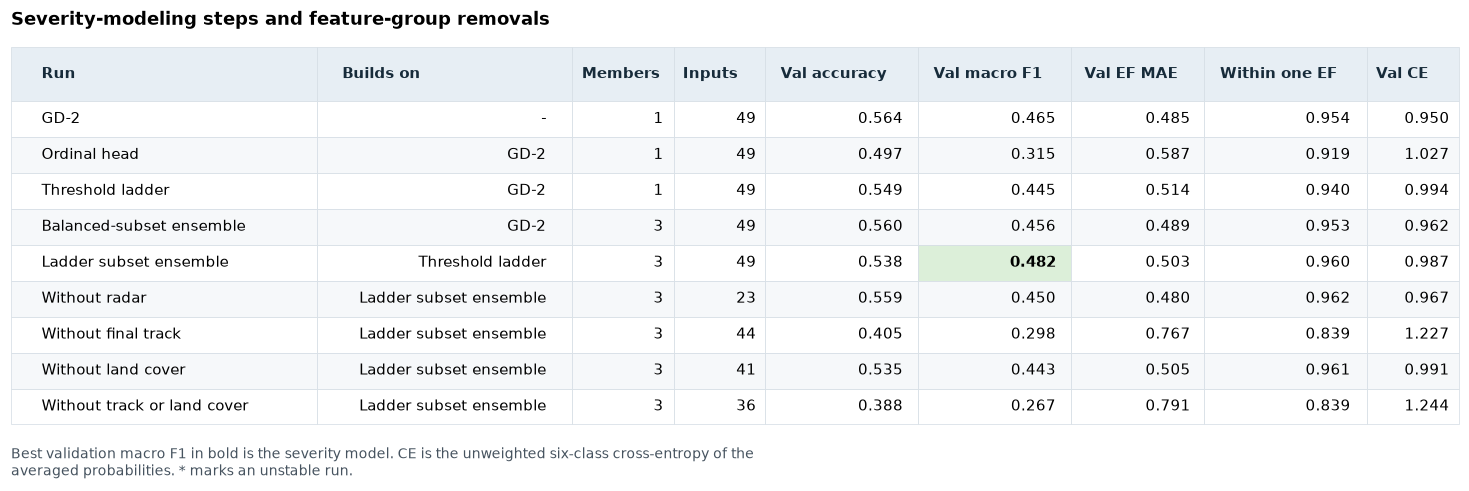

**Table 6.** Validation results for every research run. The first row is the assignment model; the severity steps build on the run named in the second column, and the feature-group removals rebuild the best step without one group of inputs.

Saved assets/tables/table_06_research_comparison.png
Saved data/results/table_06_research_comparison.csv


In [16]:
removed_groups = {
    "Without radar": ["Onset radar", "Full-window radar"],
    "Without final track": ["Final track"],
    "Without land cover": ["Land cover"],
    "Without track or land cover": ["Final track", "Land cover"],
}
feature_runs = {"All feature groups": best}
for name, groups in removed_groups.items():
    excluded = {column for group in groups for column in feature_groups[group]}
    columns = scope_columns([c for c in PREDICTORS if c not in excluded])
    feature_runs[name] = run(replace(best.config, name=name), columns=columns)

rows = [(selected, "-")] + [(result, base) for result, base, _ in step_rows[1:]]
rows += [(result, best.config.name) for name, result in feature_runs.items() if result is not best]
research_table = pd.DataFrame(
    [
        {
            "Run": result.config.name + ("" if result.completed else "*"),
            "Builds on": base,
            "Members": result.config.members,
            "Inputs": len(run_columns[result.config.name]),
            "Val accuracy": final_metric(result, "validation_accuracy"),
            "Val macro F1": final_metric(result, "validation_macro_f1"),
            "Val EF MAE": final_metric(result, "validation_ef_mae"),
            "Within one EF": final_metric(result, "validation_within_one"),
            "Val CE": final_metric(result, "validation_cross_entropy"),
        }
        for result, base in rows
    ]
)
save_table(
    research_table,
    "table_06_research_comparison",
    "Severity-modeling steps and feature-group removals",
    caption="**Table 6.** Validation results for every research run. The first row is the "
    "assignment model; the severity steps build on the run named in the second column, and the "
    "feature-group removals rebuild the best step without one group of inputs.",
    formats={
        "Members": "d",
        "Inputs": "d",
        "Val accuracy": ".3f",
        "Val macro F1": ".3f",
        "Val EF MAE": ".3f",
        "Within one EF": ".3f",
        "Val CE": ".3f",
    },
    emphasize=("Val macro F1", "max"),
    width=14,
    note="Best validation macro F1 in bold is the severity model. CE is the unweighted six-class "
    "cross-entropy of the averaged probabilities. * marks an unstable run.",
)

**Readout**

- The ladder subset ensemble is the only step that beat the SGD 0.01 softmax model, 0.482 vs
  0.465 validation macro F1, trading three points of accuracy for better balance across the
  severe classes. It is kept.
- The two threshold heads tell different stories. The cumulative ordinal head, one score against
  ordered cutpoints, fell to 0.315 by losing EF0 and EF1 accuracy. The ladder, the same five
  questions each with its own output unit, recovered to 0.445. Ordering was not the problem;
  forcing every boundary onto one severity direction was.
- The subset ensemble helped the ladder (0.445 to 0.482) but not the softmax model (0.465 to
  0.456), so its value depends on the head it wraps. The kept margin of 0.017 is one seed and
  small; only the ordinal head's drop is clearly outside seed noise.
- Final-track features dominate. Removing them drops validation macro F1 from 0.482 to 0.298 and
  accuracy from 0.538 to 0.405, and mean absolute EF error rises from 0.50 to 0.77. Track
  length, width, and duration come from the same damage survey that assigns the rating.
- Radar and land cover each cost about 0.03 to 0.04 macro F1 (0.450 and 0.443). Removing radar
  raises accuracy and lowers EF error, so its contribution is to the severe classes rather than
  the bulk of events, and it is noisy at 66% missingness.
- Location, timing, warnings, and onset radar alone reach 0.267 macro F1 and 0.388 accuracy,
  about the same as removing final track by itself, so land cover adds little once track is gone.

### Test evaluation

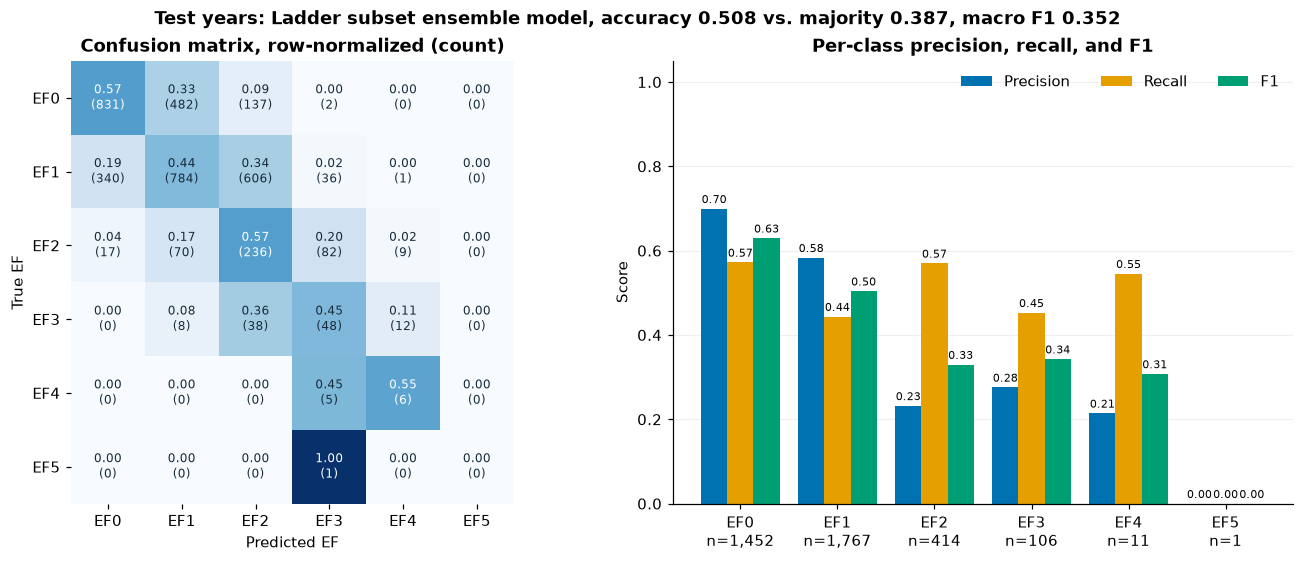

**Figure 6.** Test-year confusion matrix and per-class metrics for the Ladder subset ensemble model. Cells show the share of each true class (row) with counts in parentheses.

Saved assets/figures/fig_06_test_severity.png


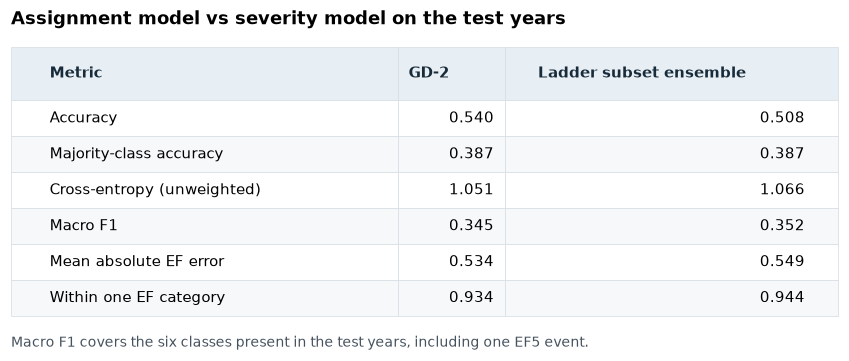

**Table 7.** Test-year results (2023-2025) for the final assignment model and the best severity model, each scored once.

Saved assets/tables/table_07_test_comparison.png
Saved data/results/table_07_test_comparison.csv


In [17]:
if best is selected:
    display(
        Markdown(
            "The assignment final model was kept; its test results are in Figure 5 and Table 5."
        )
    )
else:
    severity_test = evaluate_test(best)
    show_test_figure(best, severity_test, number=6, slug="severity")
    comparison = pd.DataFrame(
        {
            "Metric": [label for label, _ in SUMMARY_ROWS],
            selected.config.name: [assignment_test[key] for _, key in SUMMARY_ROWS],
            best.config.name: [severity_test[key] for _, key in SUMMARY_ROWS],
        }
    )
    save_table(
        comparison,
        "table_07_test_comparison",
        "Assignment model vs severity model on the test years",
        caption="**Table 7.** Test-year results (2023-2025) for the final assignment model and the "
        "best severity model, each scored once.",
        formats={selected.config.name: ".3f", best.config.name: ".3f"},
        width=8,
        note="Macro F1 covers the six classes present in the test years, including one EF5 event.",
    )

**Readout**

- On the test years the ladder subset ensemble scores 0.508 accuracy, macro F1 0.352 over six
  classes (0.423 over the five with real support), and 94% within one EF category. Against the
  assignment model's 0.540, 0.345, and 93%, it gives up three points of accuracy for a small gain
  in class balance, the same trade seen on validation.
- The gain is in the middle classes: EF2 recall rises from 0.43 to 0.57 and EF3 F1 from 0.26 to
  0.34, while EF1 recall falls from 0.55 to 0.44 because a third of EF1 events are now called
  EF2. EF4 recall is 6 of 11 and the one EF5 was predicted as EF3.
- Both models lose the same amount from validation to test, so that drop is drift in the rating
  mix, not a property of either model.

In [18]:
history = pd.concat(
    [
        result.epochs.assign(
            run=name, **{k: v for k, v in vars(result.config).items() if k != "name"}
        )
        for name, result in results.items()
    ],
    ignore_index=True,
)
history.to_csv(RESULTS_DIR / "training_history.csv", index=False)
saved(RESULTS_DIR / "training_history.csv")

Saved data/results/training_history.csv


## 7. Findings and Limitations